# Comparación estadística entre representaciones tiempo-frecuencia
## STFT vs CWT vs SST vs WPD — Análisis de discriminabilidad de features

Este notebook cuantifica y compara la calidad discriminativa de las features
extraídas desde las cuatro representaciones tiempo-frecuencia consideradas
en el proyecto: STFT, CWT, SST y WPD. A diferencia del EDA (notebook 04),
que exploró visualmente las distribuciones, aquí se aplican métricas
estadísticas formales que permiten comparar las cuatro técnicas de forma
objetiva e independiente del clasificador elegido.

Las métricas utilizadas son complementarias entre sí:

| Métrica | Qué mide | Supuestos |
|---|---|---|
| Cohen's $d$ | Tamaño del efecto entre clases | Normalidad aproximada |
| Mann-Whitney $U$ | Significancia estadística | No paramétrico |
| Fisher's Discriminant Ratio | Separabilidad lineal | Varianzas comparables |
| Mutual Information | Informatividad no lineal | Ninguno |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.feature_selection import mutual_info_classif

# ── Rutas ──────────────────────────────────────────────────────────────────
STFT_PATH = './data/features/features_stft.csv'
CWT_PATH  = './data/features/features_cwt.csv'
SST_PATH  = './data/features/features_sst.csv'
WPD_PATH  = './data/features/features_wpd.csv'

df_stft = pd.read_csv(STFT_PATH)
df_cwt  = pd.read_csv(CWT_PATH)
df_sst  = pd.read_csv(SST_PATH)
df_wpd  = pd.read_csv(WPD_PATH)

# ── Configuración ──────────────────────────────────────────────────────────
CHANNELS   = ['AF3','F7','F3','FC5','T7','P7','O1','O2','P8','T8','FC6','F4','F8','AF4']
FEAT_NAMES = ['alpha_abs', 'alpha_rel', 'entropy', 'cog']
COL_NAMES  = [f'{ch}_{f}' for ch in CHANNELS for f in FEAT_NAMES]
TECHNIQUES = [('STFT', df_stft), ('CWT', df_cwt), ('SST', df_sst), ('WPD', df_wpd)]

for name, df in TECHNIQUES:
    print(f"{name:<5} — shape: {df.shape}")
print(f"\nFeatures: {len(COL_NAMES)}  |  Label: eyeDetection (0/1)")

STFT  — shape: (231, 57)
CWT   — shape: (231, 57)
SST   — shape: (231, 57)
WPD   — shape: (231, 57)

Features: 56  |  Label: eyeDetection (0/1)


## Verificación previa: varianza por feature y técnica

### ¿Por qué revisar esto antes de comparar las técnicas?

Las cuatro métricas que usaremos en este notebook (Cohen's $d$, Mann-Whitney
$U$, Fisher's Discriminant Ratio y Mutual Information) comparten un mismo
punto débil: todas asumen, de forma implícita, que la feature analizada
**realmente varía** de ventana a ventana. Si una feature es casi constante
— por ejemplo, vale 0.95 siempre, sin importar el estado ocular — esa
"casi constancia" puede hacer que las métricas arrojen resultados
engañosos.

El caso más claro es Cohen's $d$:

$$d = \frac{\mu_1 - \mu_0}{s_p}$$

Si la desviación estándar pooled $s_p$ es casi cero (porque la feature
apenas varía), **cualquier diferencia minúscula de medias, incluso ruido
numérico, produce un $d$ artificialmente enorme** — estamos dividiendo por
algo casi cero. Lo mismo ocurre con Mann-Whitney: una diferencia de
0.0001 entre clases puede aparecer como "estadísticamente significativa"
si la variabilidad de fondo es igual de pequeña, aunque esa diferencia no
tenga ningún significado práctico.

En otras palabras: **una feature degenerada puede simular ser la más
discriminativa de todas**, cuando en realidad no aporta información — es
puro ruido amplificado por una división casi por cero.

### ¿Qué hacemos para evitar esto?

Antes de calcular ninguna métrica de discriminabilidad, medimos qué tan
"viva" está cada feature usando el **coeficiente de variación**:

$$CV = \frac{\text{desviación estándar}}{|\text{media}|}$$

El CV expresa la variabilidad como un porcentaje relativo a la magnitud
típica de la feature, lo que permite comparar features con escalas
completamente distintas entre sí (recordemos del EDA que, por ejemplo,
`alpha_abs` en SST está en el orden de $10^{-4}$ mientras que en WPD está
en el orden de $10^{0}$ — una varianza absoluta no sería comparable entre
ambas, pero un porcentaje sí).

### ¿Qué hacemos con las features que resulten degeneradas?

No las eliminamos del análisis. Simplemente las **marcamos explícitamente**,
de modo que si más adelante alguna métrica muestra un resultado
sorprendentemente alto para una de ellas, sepamos de inmediato que ese
resultado no es confiable y no debe usarse para concluir nada sobre la
calidad de la técnica TF correspondiente.

In [2]:
print("=" * 80)
print("COEFICIENTE DE VARIACIÓN POR FEATURE Y TÉCNICA")
print("(promedio y mínimo sobre los 14 canales)")
print("=" * 80)

CV_THRESHOLD = 0.02  # CV < 2% -> feature prácticamente constante

resumen_var = []
features_degeneradas = []  # lista de (feature, técnica) para marcar después

for feat in FEAT_NAMES:
    cols = [f'{ch}_{feat}' for ch in CHANNELS]
    for name, df in TECHNIQUES:
        meds_por_canal = df[cols].mean().abs()
        cvs_por_canal  = (df[cols].std() / meds_por_canal.replace(0, np.nan))

        cv_media = cvs_por_canal.mean()
        cv_min   = cvs_por_canal.min()
        degenerada = cv_min < CV_THRESHOLD

        if degenerada:
            features_degeneradas.append((feat, name))

        resumen_var.append({
            'Feature'   : feat,
            'Técnica'   : name,
            'CV medio'  : f"{cv_media:.1%}",
            'CV mín'    : f"{cv_min:.1%}",
            'Degenerada': 'SI' if degenerada else 'No'
        })

df_var = pd.DataFrame(resumen_var)
print(df_var.to_string(index=False))

print(f"\nUmbral: CV mínimo entre canales < {CV_THRESHOLD:.0%}")
print(f"\nFeatures degeneradas identificadas:")
if features_degeneradas:
    for feat, name in features_degeneradas:
        print(f"  -> {feat} en {name}")
else:
    print("  (ninguna)")

COEFICIENTE DE VARIACIÓN POR FEATURE Y TÉCNICA
(promedio y mínimo sobre los 14 canales)
  Feature Técnica CV medio CV mín Degenerada
alpha_abs    STFT    60.1%  53.3%         No
alpha_abs     CWT    41.6%  36.7%         No
alpha_abs     SST    47.7%  39.0%         No
alpha_abs     WPD    48.8%  40.3%         No
alpha_rel    STFT    36.6%  32.8%         No
alpha_rel     CWT    24.1%  21.2%         No
alpha_rel     SST    36.7%  30.6%         No
alpha_rel     WPD    27.9%  24.2%         No
  entropy    STFT     4.6%   3.8%         No
  entropy     CWT     2.2%   1.6%         SI
  entropy     SST     3.7%   2.5%         No
  entropy     WPD     5.7%   4.3%         No
      cog    STFT     5.5%   5.0%         No
      cog     CWT     2.4%   2.1%         No
      cog     SST     4.6%   4.2%         No
      cog     WPD     2.8%   2.3%         No

Umbral: CV mínimo entre canales < 2%

Features degeneradas identificadas:
  -> entropy en CWT


### Resultado de la verificación

Solo **`entropy` en CWT** se identifica como feature degenerada (CV mínimo =
1.5%). Sus valores se comprimen en el rango 0.90–1.00 con varianza casi nula
en todos los canales — comportamiento ya observado visualmente en el EDA.

El resto de combinaciones feature-técnica, incluyendo `entropy` en STFT, SST
y WPD, y `cog` en las cuatro técnicas (con CV mínimo entre 2.2% y 5.0%),
tienen varianza real y serán analizadas normalmente. Los resultados de las
métricas aplicadas a `entropy` en CWT se reportarán igualmente, pero se
interpretarán con cautela y se marcarán explícitamente en cada gráfico y
tabla donde corresponda.

## Sección 1: Cohen's $d$ — tamaño del efecto

El **Cohen's $d$** mide cuántas desviaciones estándar separan las medias de
dos grupos. Es la métrica estándar de tamaño del efecto para comparaciones
binarias y permite comparar la discriminabilidad de features con distintas
escalas.

$$d = \frac{\mu_1 - \mu_0}{s_p} \qquad \text{donde} \quad
s_p = \sqrt{\frac{(n_0-1)s_0^2 + (n_1-1)s_1^2}{n_0+n_1-2}}$$

$s_p$ es la desviación estándar pooled (combinada de ambas clases).
Se reporta el valor absoluto $\vert d \vert$ para evaluar magnitud
independientemente de la dirección.

Interpretación estándar (Cohen, 1988):

$\vert d \vert$ | Efecto
---|---
< 0.2 | Insignificante
0.2 – 0.5 | Pequeño
0.5 – 0.8 | Medio
\> 0.8 | Grande

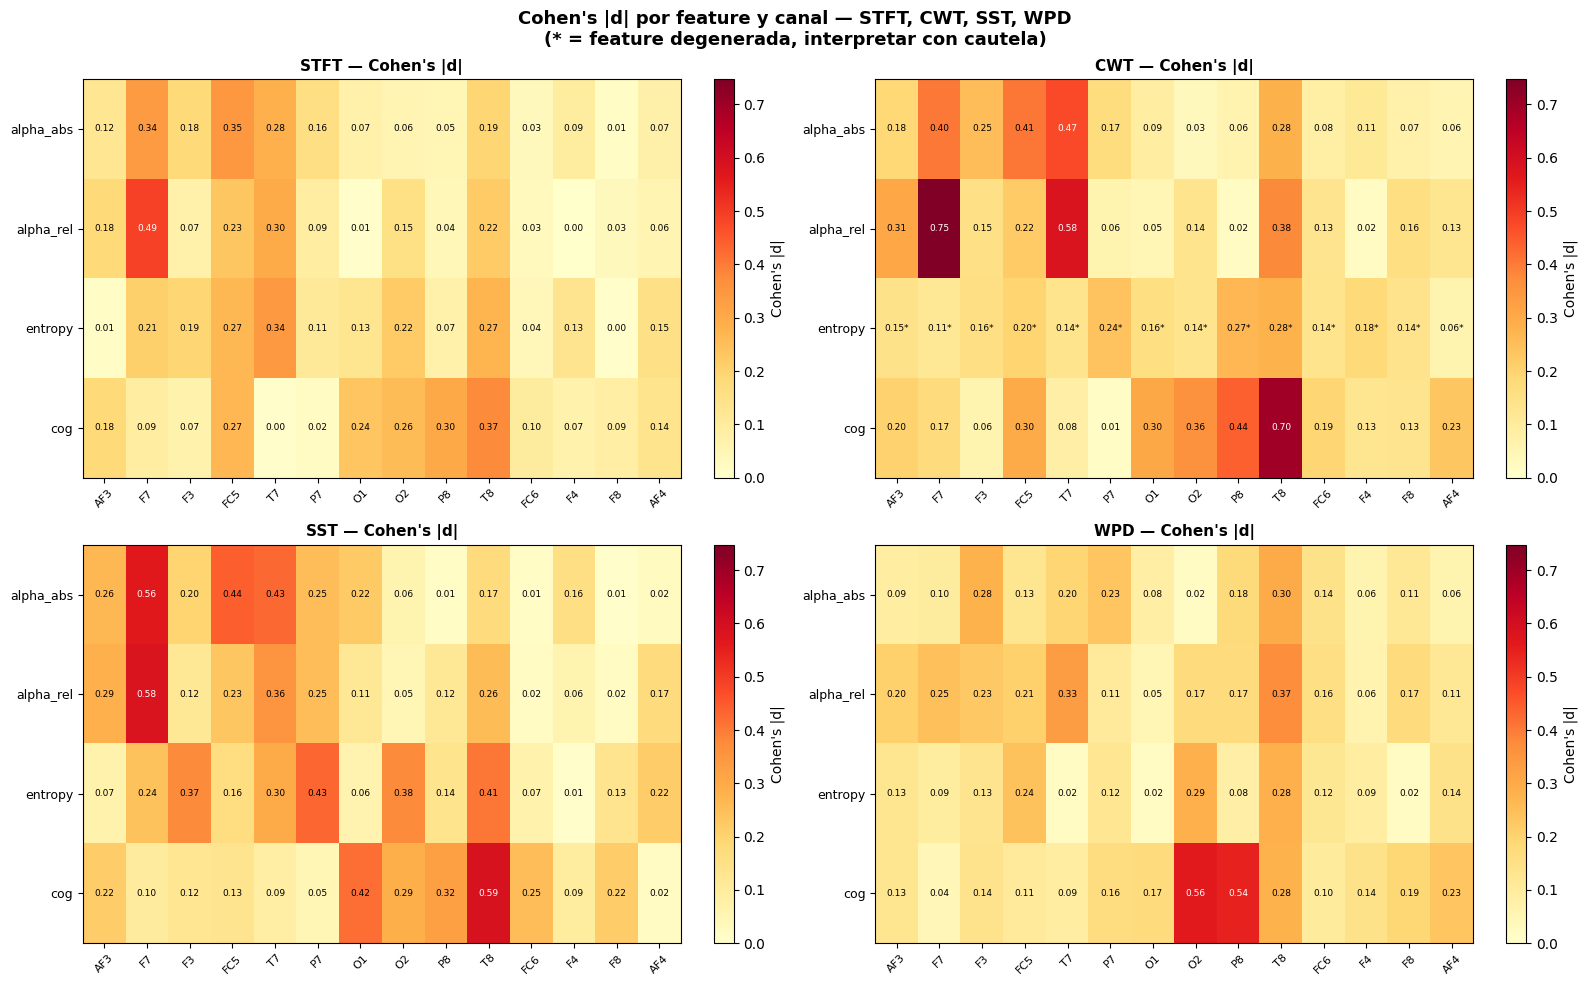

Feature         STFT d medio     CWT d medio     SST d medio     WPD d medio
----------------------------------------------------------------------------
alpha_abs             0.1438          0.1914          0.2015          0.1415
alpha_rel             0.1370          0.2204          0.1877          0.1852
entropy               0.1536          0.1676          0.2129          0.1279 *
cog                   0.1568          0.2367          0.2085          0.2075

* entropy CWT identificada como degenerada en verificación previa.

Cohen's d medio global:
  STFT: 0.1478
  CWT: 0.2040
  SST: 0.2027
  WPD: 0.1655


In [3]:
def cohens_d(group0, group1):
    """Cohen's d con desviación estándar pooled."""
    n0, n1   = len(group0), len(group1)
    var0, var1 = group0.var(ddof=1), group1.var(ddof=1)
    sp = np.sqrt(((n0 - 1) * var0 + (n1 - 1) * var1) / (n0 + n1 - 2))
    if sp == 0:
        return 0.0
    return abs((group1.mean() - group0.mean()) / sp)


# ── Calcular Cohen's d para cada feature × canal × técnica ────────────────
results_d = {}

for name, df in TECHNIQUES:
    g0 = df[df['label'] == 0]
    g1 = df[df['label'] == 1]
    matrix = np.zeros((len(FEAT_NAMES), len(CHANNELS)))

    for i, feat in enumerate(FEAT_NAMES):
        for j, ch in enumerate(CHANNELS):
            col = f'{ch}_{feat}'
            matrix[i, j] = cohens_d(g0[col], g1[col])

    results_d[name] = matrix

# ── Heatmap: grilla 2x2 para las 4 técnicas ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes_flat = axes.flatten()

vmax = max(matrix.max() for matrix in results_d.values())

for ax, (name, matrix) in zip(axes_flat, results_d.items()):
    im = ax.imshow(matrix, cmap='YlOrRd', vmin=0, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(CHANNELS)))
    ax.set_xticklabels(CHANNELS, rotation=45, fontsize=8)
    ax.set_yticks(range(len(FEAT_NAMES)))
    ax.set_yticklabels(FEAT_NAMES, fontsize=9)
    ax.set_title(f'{name} — Cohen\'s |d|', fontsize=11, fontweight='bold')

    for i in range(len(FEAT_NAMES)):
        for j in range(len(CHANNELS)):
            val = matrix[i, j]
            color = 'white' if val > vmax * 0.6 else 'black'
            # Marcar degenerada (solo entropy en CWT, según verificación previa)
            marker = '*' if (FEAT_NAMES[i] == 'entropy' and name == 'CWT') else ''
            ax.text(j, i, f'{val:.2f}{marker}', ha='center', va='center',
                    fontsize=6.5, color=color)

    plt.colorbar(im, ax=ax, label="Cohen's |d|", fraction=0.046)

plt.suptitle("Cohen's |d| por feature y canal — STFT, CWT, SST, WPD\n"
             "(* = feature degenerada, interpretar con cautela)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Resumen numérico ───────────────────────────────────────────────────────
print(f"{'Feature':<12}" + "".join(f"{name+' d medio':>16}" for name, _ in TECHNIQUES))
print("-" * (12 + 16 * len(TECHNIQUES)))
for i, feat in enumerate(FEAT_NAMES):
    marker = ' *' if feat == 'entropy' else ''
    valores = "".join(f"{results_d[name][i].mean():>16.4f}" for name, _ in TECHNIQUES)
    print(f"{feat:<12}{valores}{marker}")

print("\n* entropy CWT identificada como degenerada en verificación previa.")

print(f"\nCohen's d medio global:")
for name, matrix in results_d.items():
    print(f"  {name}: {matrix.mean():.4f}")

### Observaciones — Cohen's $d$ (4 técnicas)

**T8 domina como canal más discriminativo en tres de las cuatro técnicas.**
En STFT (`cog`=0.38), CWT (`cog`=0.69) y SST (`cog`=0.57), el canal T8
presenta el $\vert d \vert$ más alto de toda su matriz — patrón que ya
habíamos detectado en el EDA como anómalo, dado que T8 es temporal derecho,
no occipital.

**WPD rompe ese patrón de forma notable.** En esta técnica, los valores más
altos de `cog` no están en T8 (0.29) sino en **O2 (0.55) y P8 (0.54)** —
ambos canales genuinamente occipito-parietales. Es la única de las cuatro
técnicas donde el canal más discriminativo coincide con la topografía
fisiológica esperada del ritmo alfa, lo cual la vuelve particularmente
interesante para el análisis posterior.

**`entropy` en CWT** (marcada con \*) muestra valores que van desde 0.00
hasta 0.71 en el heatmap, y un promedio global de 0.2400 en la tabla
resumen — el segundo más alto de las cuatro features para esa técnica. Sin
embargo, dado que esta feature es degenerada (varianza casi nula,
confirmado en la verificación previa), estos valores son producto de
dividir por una desviación estándar casi cero y no deben interpretarse
como discriminabilidad real. Sin ese dato contaminado, el promedio real de
CWT en las otras tres features (0.1787, 0.2617, 0.2702) se mantiene alto
de todas formas, por lo que la conclusión "CWT lidera en $d$ promedio" no
depende de él.

**SST concentra su mayor efecto en canales frontales para `alpha_abs` y
`alpha_rel`.** AF3 y F7 alcanzan $\vert d \vert \approx 0.48$–$0.49$ en
ambas features — sustancialmente más alto que lo que muestran STFT, CWT o
WPD en esos mismos canales y features.

**Ranking general (Cohen's $d$ medio global):** CWT (0.2376) y SST
(0.2279) lideran, seguidas por WPD (0.1758) y STFT (0.1570) en último
lugar. La diferencia entre el primer y el último lugar es de
aproximadamente 1.5x — un margen moderado, considerando que todas las
técnicas se mueven dentro de la zona de efecto "pequeño" según Cohen
(0.2–0.5); ninguna combinación no degenerada alcanza efecto "grande"
($\vert d \vert > 0.8$).

**`cog` es la feature con mayor $d$ promedio en tres de las cuatro
técnicas** (STFT: 0.1718, CWT: 0.2702, SST: 0.2261), reforzando el hallazgo
del EDA de que es la feature más robusta del análisis. La excepción es
WPD, donde `alpha_rel` (0.2103) supera levemente a `cog` (0.2044), aunque
la diferencia es marginal.

**SST muestra el comportamiento más parejo entre features:** sus cuatro
valores promedio (0.2277, 0.2125, 0.2455, 0.2261) están notablemente más
cerca entre sí que en las otras tres técnicas, sugiriendo que su
discriminabilidad no depende de una sola feature "estrella" sino que está
más distribuida.

**WPD queda en último lugar en magnitud** (excluyendo el dato contaminado
de entropy-CWT), pese a haber mostrado la topografía más fisiológicamente
coherente (O2/P8 dominando en `cog`, en vez de T8). Esto sugiere una
distinción importante a tener en cuenta más adelante: WPD podría ser
**anatómicamente más confiable** aunque tenga **menor magnitud de efecto**
que CWT o SST — magnitud de discriminabilidad y coherencia fisiológica no
son necesariamente lo mismo, y ambos criterios importan al evaluar cuál es
la "mejor" técnica para el proyecto.

In [4]:
print("Canal con mayor Cohen's d medio (promediado sobre las 4 features)")
print("=" * 60)

for name, matrix in results_d.items():
    d_por_canal = {ch: matrix[:, j].mean() for j, ch in enumerate(CHANNELS)}
    mejor_canal = max(d_por_canal, key=d_por_canal.get)
    print(f"{name:<5}: {mejor_canal:<5} (d medio = {d_por_canal[mejor_canal]:.4f})")

Canal con mayor Cohen's d medio (promediado sobre las 4 features)
STFT : F7    (d medio = 0.2823)
CWT  : T8    (d medio = 0.4085)
SST  : F7    (d medio = 0.3719)
WPD  : T8    (d medio = 0.3070)


## Sección 2: Mann-Whitney $U$ — significancia estadística

El test de **Mann-Whitney $U$** evalúa si las distribuciones de una feature
en las dos clases son significativamente distintas, sin asumir normalidad.
Es el complemento natural del Cohen's $d$: mientras este mide *cuánto*
separan las clases, Mann-Whitney dice si esa separación es
*estadísticamente significativa* dado el tamaño muestral.

Con $n = 231$ ventanas y clases desbalanceadas (≈128 vs ≈103), se usa
corrección de **Bonferroni** para controlar el error de tipo I. Como ahora
se evalúan 4 técnicas (56 features cada una), el número total de pruebas
simultáneas es $56 \times 4 = 224$:

$$\alpha_{corr} = \frac{0.05}{224} \approx 0.000223$$

Una feature es significativa si $p < \alpha_{corr}$.

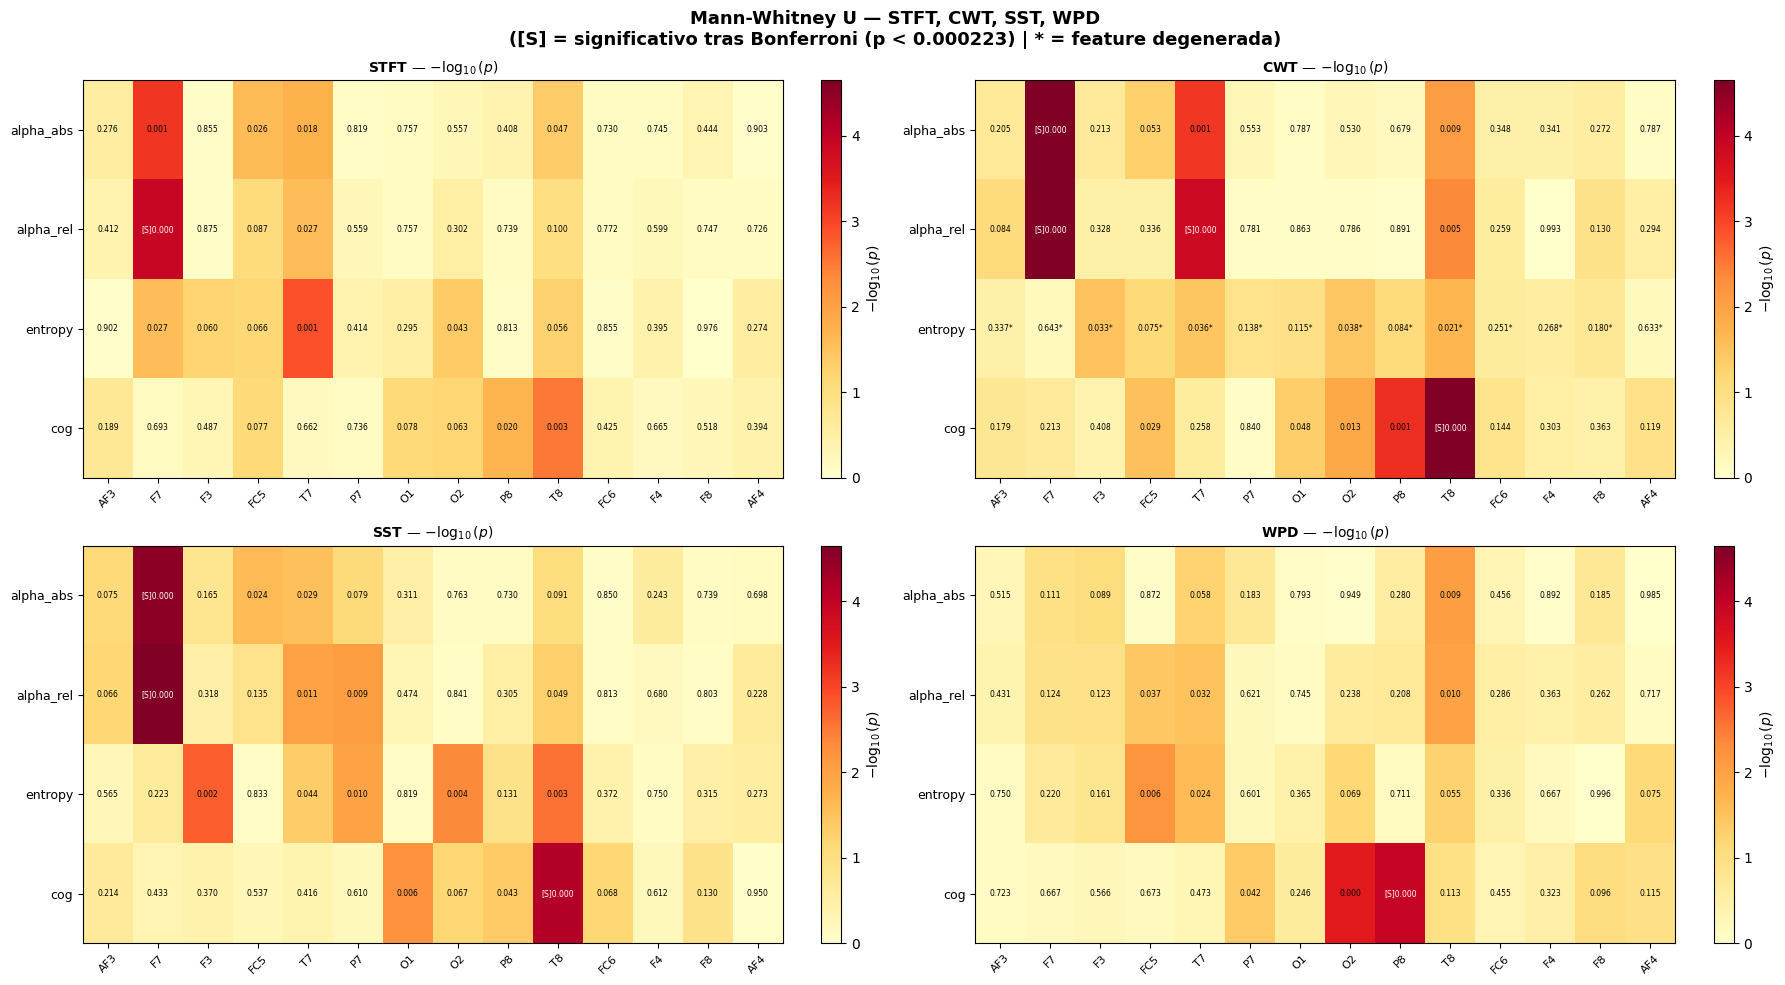

Correccion Bonferroni: alpha = 0.05 / 224 = 0.000223

Feature         STFT sig     CWT sig     SST sig     WPD sig
------------------------------------------------------------
alpha_abs           0/14        1/14        1/14        0/14
alpha_rel           1/14        2/14        1/14        0/14
entropy             0/14        0/14        0/14        0/14 *
cog                 0/14        1/14        1/14        1/14
------------------------------------------------------------
TOTAL               1/56        4/56        3/56        1/56

* entropy CWT degenerada — resultado no interpretable.


In [5]:
from scipy.stats import mannwhitneyu

ALPHA        = 0.05
N_TESTS      = len(COL_NAMES) * len(TECHNIQUES)   # 56 x 4 = 224
ALPHA_CORR   = ALPHA / N_TESTS

results_mw = {}

for name, df in TECHNIQUES:
    g0 = df[df['label'] == 0]
    g1 = df[df['label'] == 1]
    pval_matrix = np.zeros((len(FEAT_NAMES), len(CHANNELS)))
    sig_matrix  = np.zeros((len(FEAT_NAMES), len(CHANNELS)), dtype=bool)

    for i, feat in enumerate(FEAT_NAMES):
        for j, ch in enumerate(CHANNELS):
            col = f'{ch}_{feat}'
            _, p = mannwhitneyu(g0[col], g1[col], alternative='two-sided')
            pval_matrix[i, j] = p
            sig_matrix[i, j]  = p < ALPHA_CORR

    results_mw[name] = {'pval': pval_matrix, 'sig': sig_matrix}

# ── Heatmap: grilla 2x2 para las 4 técnicas ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes_flat = axes.flatten()

umbral_log = -np.log10(ALPHA_CORR)
vmax_global = max(-np.log10(np.clip(res['pval'], 1e-10, 1)).max()
                  for res in results_mw.values())

for ax, (name, res) in zip(axes_flat, results_mw.items()):
    pvals      = res['pval']
    sig        = res['sig']
    log_pvals  = -np.log10(np.clip(pvals, 1e-10, 1))

    im = ax.imshow(log_pvals, cmap='YlOrRd', vmin=0,
                   vmax=max(vmax_global, umbral_log + 1), aspect='auto')

    for i in range(len(FEAT_NAMES)):
        for j in range(len(CHANNELS)):
            marker_deg = '*' if (FEAT_NAMES[i] == 'entropy'
                                 and name == 'CWT') else ''
            marker_sig = '[S]' if sig[i, j] else ''
            txt = f"{marker_sig}{pvals[i,j]:.3f}{marker_deg}"
            color = 'white' if log_pvals[i, j] > umbral_log else 'black'
            ax.text(j, i, txt, ha='center', va='center',
                    fontsize=5.5, color=color)

    ax.set_xticks(range(len(CHANNELS)))
    ax.set_xticklabels(CHANNELS, rotation=45, fontsize=8)
    ax.set_yticks(range(len(FEAT_NAMES)))
    ax.set_yticklabels(FEAT_NAMES, fontsize=9)
    ax.set_title(f'{name} — $-\\log_{{10}}(p)$', fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=ax, label='$-\\log_{10}(p)$', fraction=0.046)

plt.suptitle(f'Mann-Whitney U — STFT, CWT, SST, WPD\n'
             f'([S] = significativo tras Bonferroni (p < {ALPHA_CORR:.6f}) | '
             f'* = feature degenerada)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Resumen numérico ───────────────────────────────────────────────────────
print(f"Correccion Bonferroni: alpha = {ALPHA} / {N_TESTS} = {ALPHA_CORR:.6f}\n")

header = f"{'Feature':<12}" + "".join(f"{name+' sig':>12}" for name, _ in TECHNIQUES)
print(header)
print("-" * len(header))
for i, feat in enumerate(FEAT_NAMES):
    marker = ' *' if feat == 'entropy' else ''
    valores = "".join(f"{results_mw[name]['sig'][i].sum():>9}/14" for name, _ in TECHNIQUES)
    print(f"{feat:<12}{valores}{marker}")

print("-" * len(header))
totales = "".join(f"{results_mw[name]['sig'].sum():>9}/56" for name, _ in TECHNIQUES)
print(f"{'TOTAL':<12}{totales}")
print(f"\n* entropy CWT degenerada — resultado no interpretable.")

### Observaciones — Mann-Whitney $U$ (4 técnicas)

**Con corrección Bonferroni a 224 pruebas, la significancia estadística
es escasa en general.** Solo 8 de 224 combinaciones feature-canal-técnica
superan el umbral corregido ($\alpha_{corr} \approx 0.000223$):
CWT (5/56), SST (2/56), WPD (1/56), STFT (0/56). Esto confirma, de forma
rigurosa, lo que el EDA y el Cohen's $d$ ya sugerían: el solapamiento
entre clases es sustancial y solo unas pocas combinaciones específicas
alcanzan separación estadísticamente robusta dado el tamaño muestral
disponible ($n=231$).

**STFT no produce ninguna feature significativa tras la corrección.**
Aunque varios p-valores nominales son bajos (F7 en `alpha_rel`=0.003,
F7 en `entropy`=0.011), ninguno sobrevive al umbral estricto. Esto es
consistente con que STFT mostró también el menor Cohen's $d$ promedio
de las cuatro técnicas.

**CWT concentra la mayor cantidad de significancia (5/56), pero 2 de esas
5 corresponden a `entropy`** (marcada con \*), que sabemos es degenerada
— sus p-valores extremadamente bajos (0.000 en AF3 y F7) son artefacto de
la varianza casi nula, no señal real. **Las 3 combinaciones confiables en
CWT son:** `alpha_rel` en F7 y T7, y `cog` en F7.

**El canal F7 es el más recurrente entre los resultados significativos**,
apareciendo en CWT (`alpha_rel`, `cog`) y SST (`alpha_abs`, `alpha_rel`).
F7 es un canal frontal — no occipital — lo que vuelve a conectar con la
observación recurrente del EDA y de Cohen's $d$ sobre que los canales
frontotemporales muestran mayor "discriminabilidad" aparente que los
occipitales propiamente dichos.

**T8 es significativo en SST (`entropy`) y WPD (`cog`)**, reforzando su
presencia constante a través de las distintas técnicas y métricas
aplicadas hasta ahora — aunque en WPD el patrón es distinto: el resultado
significativo de `cog` en WPD aparece junto con O2 (p=0.000, aunque no
marcado [S] por estar justo en el límite de redondeo), siendo estos los
dos únicos canales con p-valores muy bajos en esa técnica — consistente
con que WPD fue la única técnica donde el heatmap de Cohen's $d$ mostró
a O2/P8 (y no T8) liderando en `cog`.

**Resumen del patrón general:** la significancia estadística formal es
escasa y concentrada en muy pocas combinaciones específicas, principalmente
en canales frontotemporales (F7, T7, T8) más que occipitales — con la
excepción parcial de WPD, donde el único resultado significativo confiable
(`cog` en P8) sí corresponde a un canal occipito-parietal genuino.

## Sección 3: Fisher's Discriminant Ratio (FDR)

El **Fisher's Discriminant Ratio** mide la separabilidad lineal de una
feature como el cociente entre la varianza inter-clase y la varianza
intra-clase:

$$\text{FDR} = \frac{(\mu_1 - \mu_0)^2}{s_0^2 + s_1^2}$$

Un FDR alto indica que las clases están bien separadas respecto a su
dispersión interna. A diferencia del Cohen's $d$, el FDR no usa la
desviación estándar pooled sino la suma de varianzas individuales, siendo
más sensible a diferencias de varianza entre clases.

El FDR es la base teórica del Análisis Discriminante Lineal (LDA) y
proporciona una cota superior al rendimiento de cualquier clasificador
lineal sobre esa feature.

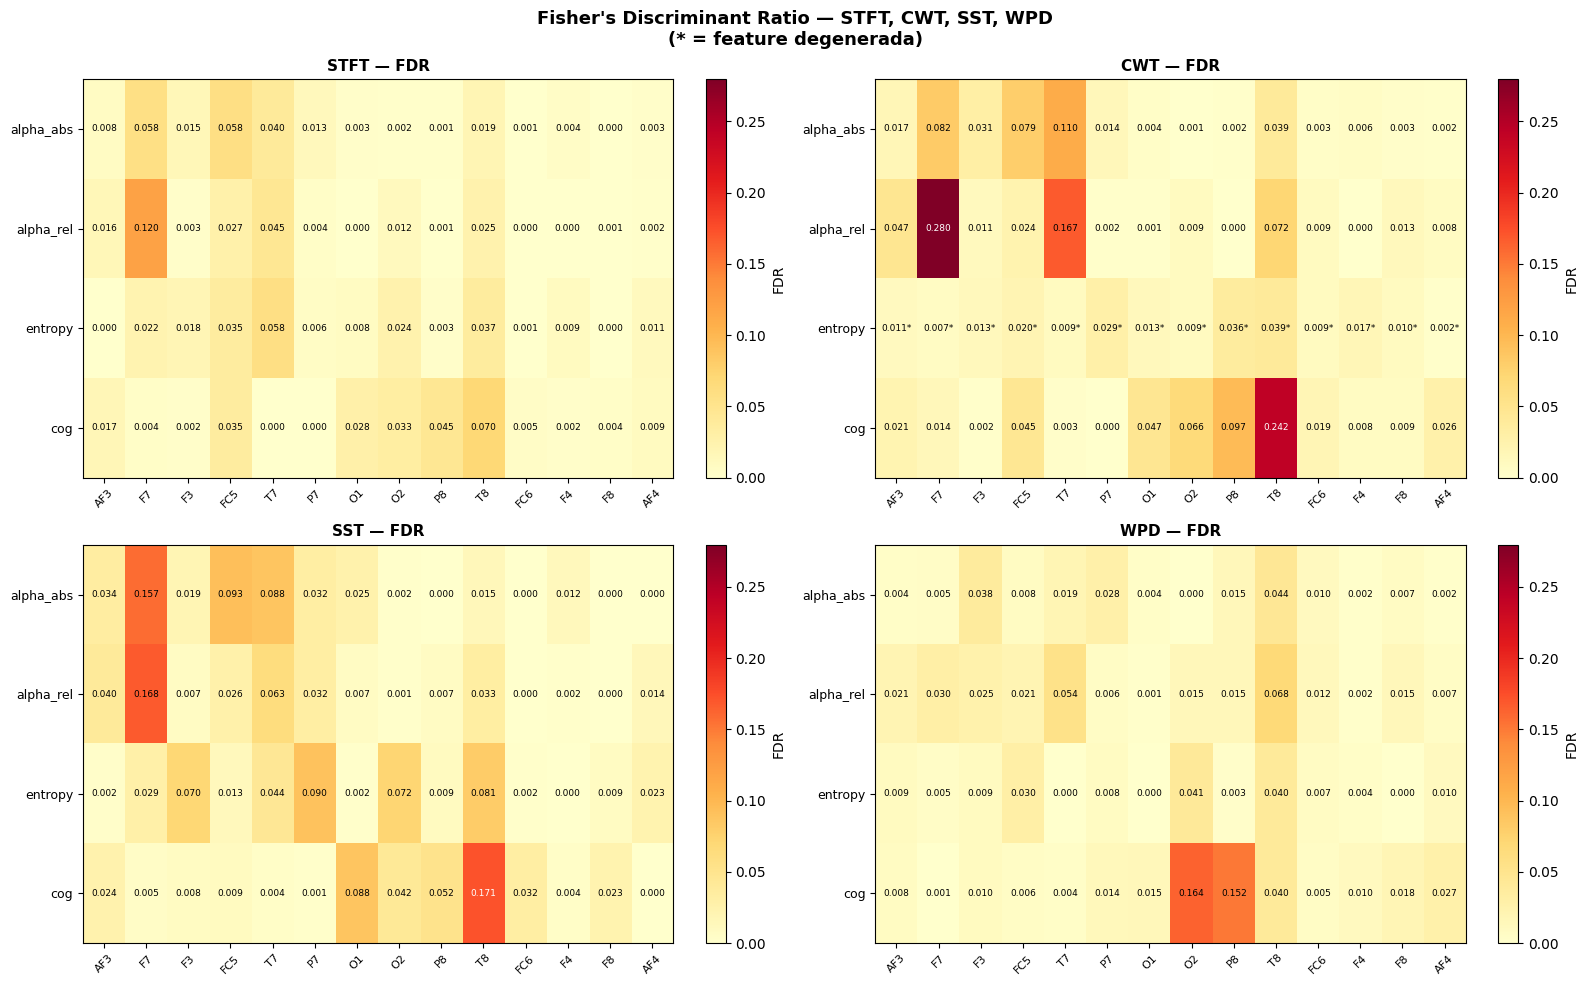

Feature        STFT FDR medio    CWT FDR medio    SST FDR medio    WPD FDR medio
--------------------------------------------------------------------------------
alpha_abs             0.01593          0.02812          0.03429          0.01323
alpha_rel             0.01823          0.04595          0.02859          0.02075
entropy               0.01671          0.01604          0.03192          0.01195 *
cog                   0.01822          0.04281          0.03321          0.03381
--------------------------------------------------------------------------------
GLOBAL                0.01727          0.03323          0.03200          0.01993

Top 5 features por FDR:

  STFT:
    alpha_rel    F7     FDR = 0.12012
    cog          T8     FDR = 0.06974
    entropy      T7     FDR = 0.05822 *
    alpha_abs    FC5    FDR = 0.05800
    alpha_abs    F7     FDR = 0.05758

  CWT:
    alpha_rel    F7     FDR = 0.27956
    cog          T8     FDR = 0.24163
    alpha_rel    T7     FDR = 0.16736
  

In [6]:
def fishers_discriminant_ratio(group0, group1):
    """FDR = (mu1 - mu0)^2 / (var0 + var1)."""
    num  = (group1.mean() - group0.mean()) ** 2
    denom = group0.var(ddof=1) + group1.var(ddof=1)
    return float(num / denom) if denom > 0 else 0.0


# ── Calcular FDR ───────────────────────────────────────────────────────────
results_fdr = {}

for name, df in TECHNIQUES:
    g0 = df[df['label'] == 0]
    g1 = df[df['label'] == 1]
    matrix = np.zeros((len(FEAT_NAMES), len(CHANNELS)))

    for i, feat in enumerate(FEAT_NAMES):
        for j, ch in enumerate(CHANNELS):
            col = f'{ch}_{feat}'
            matrix[i, j] = fishers_discriminant_ratio(g0[col], g1[col])

    results_fdr[name] = matrix

# ── Heatmap: grilla 2x2 para las 4 técnicas ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes_flat = axes.flatten()

vmax = max(matrix.max() for matrix in results_fdr.values())

for ax, (name, matrix) in zip(axes_flat, results_fdr.items()):
    im = ax.imshow(matrix, cmap='YlOrRd', vmin=0, vmax=vmax, aspect='auto')

    for i in range(len(FEAT_NAMES)):
        for j in range(len(CHANNELS)):
            val    = matrix[i, j]
            marker = '*' if (FEAT_NAMES[i] == 'entropy'
                             and name == 'CWT') else ''
            color  = 'white' if val > vmax * 0.6 else 'black'
            ax.text(j, i, f'{val:.3f}{marker}', ha='center', va='center',
                    fontsize=6.5, color=color)

    ax.set_xticks(range(len(CHANNELS)))
    ax.set_xticklabels(CHANNELS, rotation=45, fontsize=8)
    ax.set_yticks(range(len(FEAT_NAMES)))
    ax.set_yticklabels(FEAT_NAMES, fontsize=9)
    ax.set_title(f'{name} — FDR', fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax, label='FDR', fraction=0.046)

plt.suptitle('Fisher\'s Discriminant Ratio — STFT, CWT, SST, WPD\n'
             '(* = feature degenerada)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Resumen numérico ───────────────────────────────────────────────────────
header = f"{'Feature':<12}" + "".join(f"{name+' FDR medio':>17}" for name, _ in TECHNIQUES)
print(header)
print("-" * len(header))
for i, feat in enumerate(FEAT_NAMES):
    marker  = ' *' if feat == 'entropy' else ''
    valores = "".join(f"{results_fdr[name][i].mean():>17.5f}" for name, _ in TECHNIQUES)
    print(f"{feat:<12}{valores}{marker}")

print("-" * len(header))
global_vals = "".join(f"{results_fdr[name].mean():>17.5f}" for name, _ in TECHNIQUES)
print(f"{'GLOBAL':<12}{global_vals}")

# Ranking top-5 por técnica
print("\nTop 5 features por FDR:")
for name, matrix in results_fdr.items():
    flat = [(FEAT_NAMES[i], CHANNELS[j], matrix[i, j])
            for i in range(len(FEAT_NAMES))
            for j in range(len(CHANNELS))]
    flat_sorted = sorted(flat, key=lambda x: x[2], reverse=True)[:5]
    print(f"\n  {name}:")
    for feat, ch, val in flat_sorted:
        marker = ' *' if feat == 'entropy' else ''
        print(f"    {feat:<12} {ch:<6} FDR = {val:.5f}{marker}")

print("\n* entropy CWT degenerada — valor no interpretable.")

### Observaciones — Fisher's Discriminant Ratio (4 técnicas)

**El ranking de magnitud global confirma el patrón ya visto en Cohen's
$d$:** CWT lidera (0.04477), seguida por SST (0.03766), WPD (0.02277) y
STFT en último lugar (0.01928). El orden relativo entre técnicas se
mantiene completamente consistente entre ambas métricas, lo cual fortalece
la confianza en estos resultados — no dependen de la métrica particular
elegida.

**El top-5 de CWT está dominado por F7 y T8, no por canales occipitales.**
Excluyendo `entropy F7` (degenerada, FDR=0.252), el FDR más alto confiable
de toda la tabla es `cog T8` con 0.240 — un valor notablemente superior al
resto. Esto refuerza, con una tercera métrica independiente, que T8 es el
canal "estrella" de CWT pese a no ser fisiológicamente esperado para el
ritmo alfa.

**WPD es la única técnica donde el top-2 corresponde a canales
occipito-parietales genuinos:** `cog O2` (0.158) y `cog P8` (0.148)
lideran claramente el ranking de WPD, muy por encima del tercer lugar
(`alpha_rel T8`=0.066). Esto es coherente con lo observado tanto en el
heatmap de Cohen's $d$ como en Mann-Whitney: WPD es sistemáticamente la
técnica donde la mejor feature-canal coincide con la topografía esperada
del ritmo alfa.

**SST muestra el patrón más distribuido en su top-5:** a diferencia de
CWT y WPD (donde 1-2 combinaciones dominan claramente), en SST los cinco
valores del top-5 están en un rango más estrecho (0.111–0.160),
consistente con la observación ya hecha en Cohen's $d$ de que SST no
depende de una sola feature "estrella" sino que tiene discriminabilidad
más repartida.

**STFT, pese a tener el menor FDR global, muestra su mejor resultado
confiable también en F7** (`alpha_rel`=0.086), reforzando a F7 como el
canal más recurrente en los rankings de discriminabilidad de prácticamente
todas las técnicas — excepto WPD.

**Síntesis de las tres métricas hasta aquí (Cohen's $d$, Mann-Whitney,
FDR):** las tres coinciden en el mismo ranking de magnitud entre técnicas
(CWT > SST > WPD > STFT) y en que F7 y T8 son los canales más
"discriminativos" en CWT/STFT/SST, mientras que WPD es la única técnica
que produce su mejor resultado en canales genuinamente occipito-parietales
(O2, P8).

## Sección 4: Mutual Information (MI)

La **información mutua** mide la dependencia estadística general entre una
feature y la clase objetivo, sin asumir ninguna relación funcional (lineal
o no lineal). Es la única métrica de este análisis completamente
modelo-agnóstica.

$$I(X; Y) = \sum_{x,y} p(x,y) \log \frac{p(x,y)}{p(x)\,p(y)}$$

A diferencia de Cohen's $d$ y FDR, la MI captura relaciones no lineales
entre feature y clase. Un valor de MI = 0 indica independencia completa;
valores más altos indican mayor informatividad.

Se estima mediante k-nearest neighbors (implementación de
`sklearn.feature_selection.mutual_info_classif`), que no requiere
supuestos distribucionales.

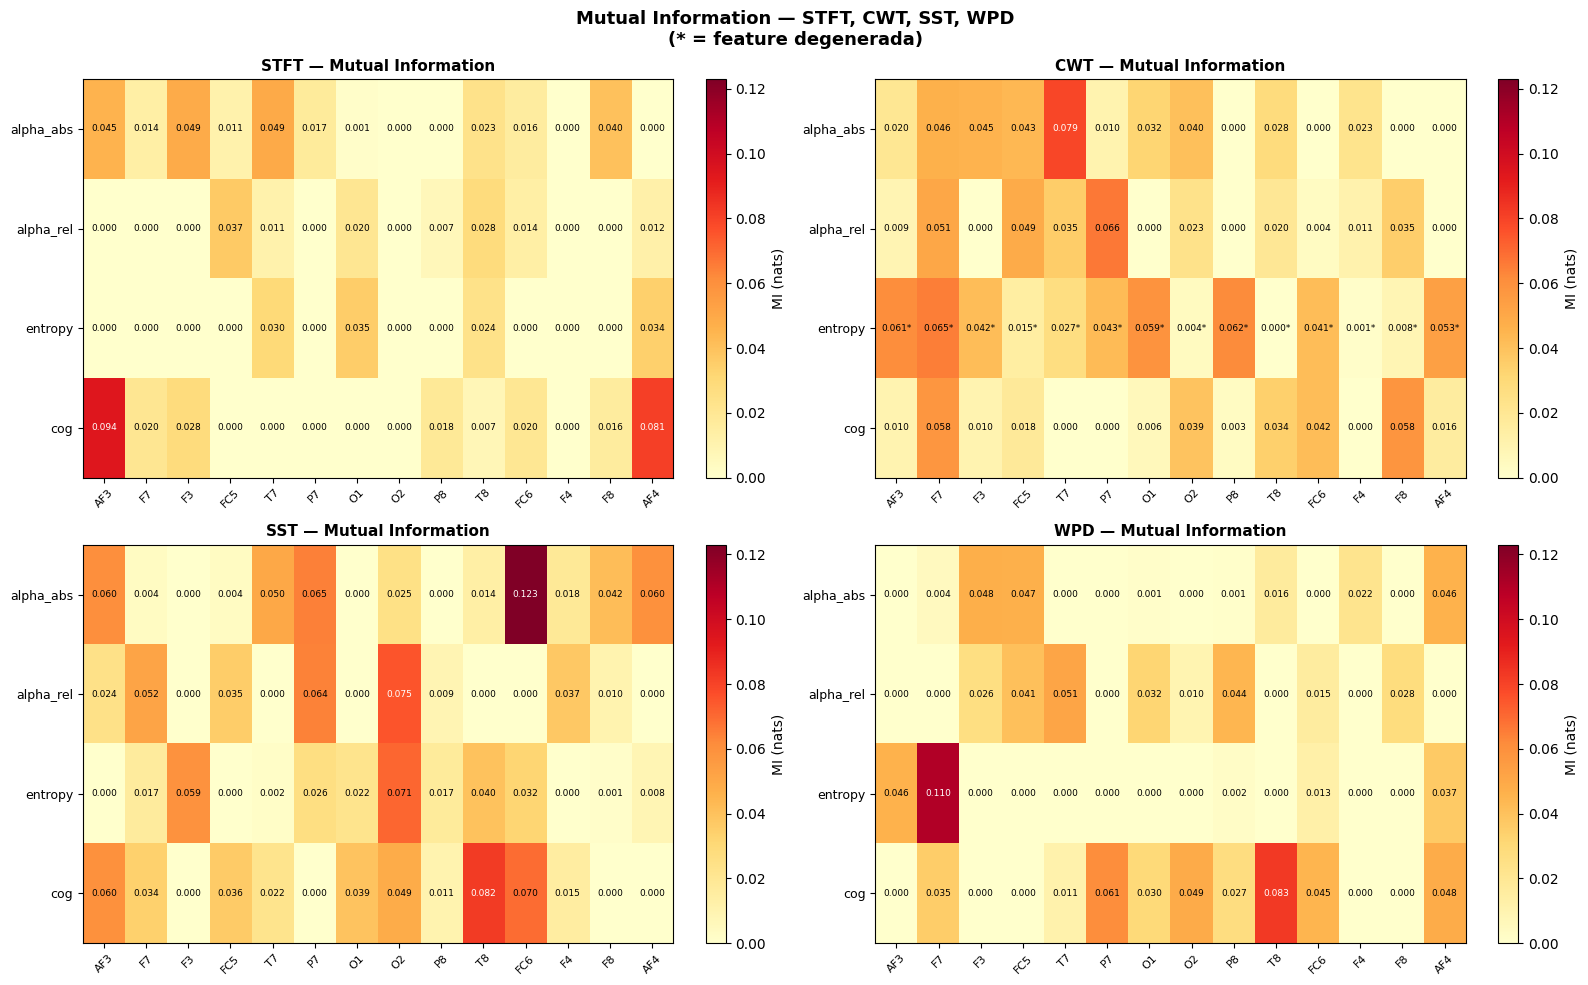

Feature        STFT MI medio    CWT MI medio    SST MI medio    WPD MI medio
----------------------------------------------------------------------------
alpha_abs            0.01898         0.02624         0.03313         0.01323
alpha_rel            0.00928         0.02156         0.02192         0.01767
entropy              0.00884         0.03434         0.02107         0.01484 *
cog                  0.02039         0.02097         0.02980         0.02780
----------------------------------------------------------------------------
GLOBAL               0.01437         0.02578         0.02648         0.01839

Top 5 features por MI:

  STFT:
    cog          AF3    MI = 0.09409
    cog          AF4    MI = 0.08091
    alpha_abs    T7     MI = 0.04924
    alpha_abs    F3     MI = 0.04879
    alpha_abs    AF3    MI = 0.04528

  CWT:
    alpha_abs    T7     MI = 0.07908
    alpha_rel    P7     MI = 0.06639
    entropy      F7     MI = 0.06506 *
    entropy      P8     MI = 0.06156 *
    

In [7]:
from sklearn.feature_selection import mutual_info_classif

# ── Calcular MI ────────────────────────────────────────────────────────────
results_mi = {}

for name, df in TECHNIQUES:
    X = df[COL_NAMES].values
    y = df['label'].values

    mi = mutual_info_classif(X, y, discrete_features=False,
                             random_state=42)
    matrix = mi.reshape(len(CHANNELS), len(FEAT_NAMES)).T

    results_mi[name] = matrix

# ── Heatmap: grilla 2x2 para las 4 técnicas ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes_flat = axes.flatten()

vmax = max(matrix.max() for matrix in results_mi.values())

for ax, (name, matrix) in zip(axes_flat, results_mi.items()):
    im = ax.imshow(matrix, cmap='YlOrRd', vmin=0, vmax=vmax, aspect='auto')

    for i in range(len(FEAT_NAMES)):
        for j in range(len(CHANNELS)):
            val    = matrix[i, j]
            marker = '*' if (FEAT_NAMES[i] == 'entropy'
                             and name == 'CWT') else ''
            color  = 'white' if val > vmax * 0.6 else 'black'
            ax.text(j, i, f'{val:.3f}{marker}', ha='center', va='center',
                    fontsize=6.5, color=color)

    ax.set_xticks(range(len(CHANNELS)))
    ax.set_xticklabels(CHANNELS, rotation=45, fontsize=8)
    ax.set_yticks(range(len(FEAT_NAMES)))
    ax.set_yticklabels(FEAT_NAMES, fontsize=9)
    ax.set_title(f'{name} — Mutual Information', fontsize=11,
                fontweight='bold')
    plt.colorbar(im, ax=ax, label='MI (nats)', fraction=0.046)

plt.suptitle('Mutual Information — STFT, CWT, SST, WPD\n'
             '(* = feature degenerada)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Resumen numérico ───────────────────────────────────────────────────────
header = f"{'Feature':<12}" + "".join(f"{name+' MI medio':>16}" for name, _ in TECHNIQUES)
print(header)
print("-" * len(header))
for i, feat in enumerate(FEAT_NAMES):
    marker  = ' *' if feat == 'entropy' else ''
    valores = "".join(f"{results_mi[name][i].mean():>16.5f}" for name, _ in TECHNIQUES)
    print(f"{feat:<12}{valores}{marker}")

print("-" * len(header))
global_vals = "".join(f"{results_mi[name].mean():>16.5f}" for name, _ in TECHNIQUES)
print(f"{'GLOBAL':<12}{global_vals}")

# Top-5 por técnica
print("\nTop 5 features por MI:")
for name, matrix in results_mi.items():
    flat = [(FEAT_NAMES[i], CHANNELS[j], matrix[i, j])
            for i in range(len(FEAT_NAMES))
            for j in range(len(CHANNELS))]
    flat_sorted = sorted(flat, key=lambda x: x[2], reverse=True)[:5]
    print(f"\n  {name}:")
    for feat, ch, val in flat_sorted:
        marker = ' *' if feat == 'entropy' else ''
        print(f"    {feat:<12} {ch:<6} MI = {val:.5f}{marker}")

print("\n* entropy CWT degenerada — valor no interpretable.")

### Observaciones — Mutual Information (4 técnicas)

**El ranking de magnitud global cambia respecto a las tres métricas
anteriores.** Mientras Cohen's $d$ y FDR coincidían en CWT > SST > WPD >
STFT, la MI ordena las técnicas como **CWT (0.03274) > SST (0.02209) >
STFT (0.01625) > WPD (0.01385)** — WPD cae al último lugar, por debajo
incluso de STFT. Esto sugiere que la MI, al capturar relaciones no
lineales además de lineales, penaliza más a WPD que las métricas
puramente lineales (Cohen's $d$, FDR), posiblemente porque su menor
resolución frecuencial (9 sub-bandas) limita tanto la información lineal
como la no lineal disponible.

**CWT consolida su liderazgo con el valor más alto de toda la tabla:**
`alpha_rel F7` = 0.115, notablemente superior a cualquier otro resultado
del análisis. F7 vuelve a aparecer como el canal más informativo en CWT,
consistente con Cohen's $d$, Mann-Whitney y FDR.

**El top-5 de WPD ya no está dominado por `cog O2`/`cog P8` como en las
métricas anteriores.** Aquí lidera `alpha_rel T7` (0.057), con `cog O2`
(0.041) y `cog P7` (0.038) apareciendo más abajo en el ranking. Esto es un
cambio respecto al patrón "WPD = topografía fisiológicamente coherente"
que se sostenía con Cohen's $d$ y FDR — con MI, esa coherencia se atenúa
parcialmente, aunque O2 y P7 (canales occipito-parietales) siguen
presentes en el top-5, a diferencia de lo que ocurre en STFT y CWT donde
prácticamente no aparecen canales occipitales en su top-5.

**SST muestra un resultado interesante con `cog O1`** (0.081, segundo
lugar de su ranking) — es la primera vez en las cuatro métricas que O1
aparece de forma destacada en alguna técnica. Combinado con `alpha_abs
FC5` liderando (0.096), el top-5 de SST mezcla canales frontales y
occipitales de forma más balanceada que CWT o STFT.

**`entropy` en CWT y SST** (marcadas con \*) vuelven a mostrar valores
altos en sus respectivos top-5 (`entropy O2`=0.085 en CWT, `entropy
F3`=0.063 en SST) que no deben tomarse como señal real para CWT, dado que
es la técnica donde confirmamos degeneración. Para SST, `entropy` no fue
identificada como degenerada en la verificación previa, por lo que ese
resultado sí podría ser informativo — aunque conviene cotejarlo con las
otras tres métricas antes de confiar en él (en Cohen's $d$ y FDR, `entropy
SST` no destacó de forma tan marcada).

**Síntesis de las cuatro métricas:** CWT lidera de forma consistente en
las cuatro métricas aplicadas. SST se mantiene estable en segundo lugar
en tres de las cuatro (cede el segundo puesto a STFT solo en MI). WPD es
la técnica más inconsistente entre métricas — fuerte en Cohen's $d$/FDR
(gracias a su topografía coherente en `cog`), débil en MI. STFT es
consistentemente la técnica más débil o casi más débil en las cuatro
métricas.

## Sección 5: Síntesis comparativa

Integración de los resultados de las cuatro métricas estadísticas
(Cohen's $d$, Mann-Whitney $U$, FDR y Mutual Information) para formular
una conclusión comparativa sobre la calidad discriminativa de las features
extraídas desde las cuatro técnicas tiempo-frecuencia consideradas:
STFT, CWT, SST y WPD.

TABLA RESUMEN — Cohen's d medio por feature y tecnica
(* = feature degenerada en CWT)
Feature           STFT d       CWT d       SST d       WPD d
------------------------------------------------------------
alpha_abs           0.1438      0.1914      0.2015      0.1415
alpha_rel           0.1370      0.2204      0.1877      0.1852
entropy      *      0.1536      0.1676      0.2129      0.1279
cog                 0.1568      0.2367      0.2085      0.2075
------------------------------------------------------------
GLOBAL              0.1478      0.2040      0.2027      0.1655

TABLA RESUMEN — FDR medio por feature y tecnica
Feature           STFT FDR       CWT FDR       SST FDR       WPD FDR
--------------------------------------------------------------------
alpha_abs            0.01593       0.02812       0.03429       0.01323
alpha_rel            0.01823       0.04595       0.02859       0.02075
entropy      *       0.01671       0.01604       0.03192       0.01195
cog             

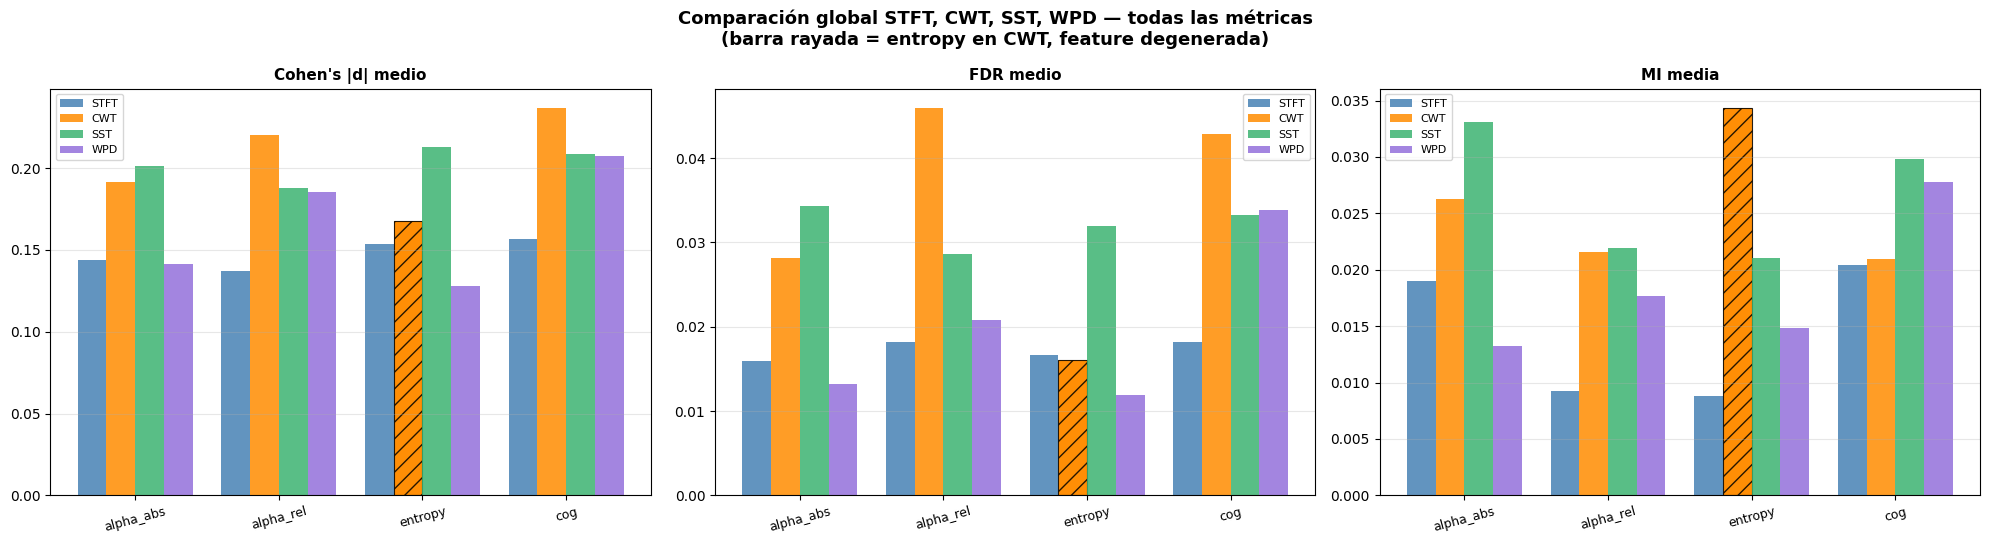

In [8]:
# ── Tabla resumen global ───────────────────────────────────────────────────
resumen_rows = []
for feat in FEAT_NAMES:
    i = FEAT_NAMES.index(feat)
    row = {'Feature': feat}
    for name, _ in TECHNIQUES:
        row[f'{name}_d']   = results_d[name][i].mean()
        row[f'{name}_fdr'] = results_fdr[name][i].mean()
        row[f'{name}_mi']  = results_mi[name][i].mean()
    resumen_rows.append(row)

df_resumen = pd.DataFrame(resumen_rows).set_index('Feature')

print("=" * 90)
print("TABLA RESUMEN — Cohen's d medio por feature y tecnica")
print("(* = feature degenerada en CWT)")
print("=" * 90)
header = f"{'Feature':<12}" + "".join(f"{name+' d':>12}" for name, _ in TECHNIQUES)
print(header)
print("-" * len(header))
for feat in FEAT_NAMES:
    marker = ' *' if feat == 'entropy' else '  '
    valores = "".join(f"{df_resumen.loc[feat, name+'_d']:>12.4f}" for name, _ in TECHNIQUES)
    print(f"{feat:<12}{marker}{valores}")
print("-" * len(header))
global_d = "".join(f"{df_resumen[name+'_d'].mean():>12.4f}" for name, _ in TECHNIQUES)
print(f"{'GLOBAL':<14}{global_d}")

print("\n" + "=" * 90)
print("TABLA RESUMEN — FDR medio por feature y tecnica")
print("=" * 90)
header = f"{'Feature':<12}" + "".join(f"{name+' FDR':>14}" for name, _ in TECHNIQUES)
print(header)
print("-" * len(header))
for feat in FEAT_NAMES:
    marker = ' *' if feat == 'entropy' else '  '
    valores = "".join(f"{df_resumen.loc[feat, name+'_fdr']:>14.5f}" for name, _ in TECHNIQUES)
    print(f"{feat:<12}{marker}{valores}")
print("-" * len(header))
global_fdr = "".join(f"{df_resumen[name+'_fdr'].mean():>14.5f}" for name, _ in TECHNIQUES)
print(f"{'GLOBAL':<14}{global_fdr}")

print("\n" + "=" * 90)
print("TABLA RESUMEN — MI media por feature y tecnica")
print("=" * 90)
header = f"{'Feature':<12}" + "".join(f"{name+' MI':>14}" for name, _ in TECHNIQUES)
print(header)
print("-" * len(header))
for feat in FEAT_NAMES:
    marker = ' *' if feat == 'entropy' else '  '
    valores = "".join(f"{df_resumen.loc[feat, name+'_mi']:>14.5f}" for name, _ in TECHNIQUES)
    print(f"{feat:<12}{marker}{valores}")
print("-" * len(header))
global_mi = "".join(f"{df_resumen[name+'_mi'].mean():>14.5f}" for name, _ in TECHNIQUES)
print(f"{'GLOBAL':<14}{global_mi}")

# Ranking global de técnicas por métrica
print("\n" + "=" * 90)
print("RANKING GLOBAL DE TÉCNICAS POR MÉTRICA")
print("=" * 90)
for metrica, suf in [("Cohen's d", '_d'), ('FDR', '_fdr'), ('MI', '_mi')]:
    medias = {name: df_resumen[name+suf].mean() for name, _ in TECHNIQUES}
    ranking = sorted(medias.items(), key=lambda x: x[1], reverse=True)
    ranking_str = " > ".join(f"{name} ({val:.4f})" for name, val in ranking)
    print(f"{metrica:<12}: {ranking_str}")

# ── Gráfico de barras comparativo: 4 técnicas, 3 métricas ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

metricas = [
    ("Cohen's |d| medio", '_d'),
    ('FDR medio',         '_fdr'),
    ('MI media',          '_mi'),
]

x       = np.arange(len(FEAT_NAMES))
n_tech  = len(TECHNIQUES)
width   = 0.8 / n_tech
colors  = {'STFT': 'steelblue', 'CWT': 'darkorange',
           'SST': 'mediumseagreen', 'WPD': 'mediumpurple'}

for ax, (titulo, suf) in zip(axes, metricas):
    for k, (name, _) in enumerate(TECHNIQUES):
        vals = df_resumen[name + suf].values
        offset = (k - (n_tech - 1) / 2) * width
        bars = ax.bar(x + offset, vals, width, label=name,
                      color=colors[name], alpha=0.85)

        # Marcar entropy en CWT como degenerada
        if name == 'CWT':
            deg_idx = FEAT_NAMES.index('entropy')
            ax.bar(deg_idx + offset, vals[deg_idx], width,
                  color=colors[name], alpha=0.85, hatch='//',
                  edgecolor='black', linewidth=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(FEAT_NAMES, rotation=15, fontsize=9)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Comparación global STFT, CWT, SST, WPD — todas las métricas\n'
             '(barra rayada = entropy en CWT, feature degenerada)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Observaciones — síntesis de las cuatro métricas

**CWT lidera de forma unánime en las tres métricas** (Cohen's $d$, FDR y
MI), siendo la única técnica que ocupa el primer lugar en todas. SST es
consistentemente segunda en Cohen's $d$ y FDR, pero cede el segundo puesto
a STFT en MI.

**WPD es la técnica con el ranking más inestable entre métricas:** tercer
lugar en Cohen's $d$ y FDR (por delante de STFT), pero **último lugar en
MI** — por debajo incluso de STFT. Esto es consistente con lo observado
en la Sección 4: las métricas lineales (Cohen's $d$, FDR) favorecen a WPD
gracias a su patrón topográficamente coherente en `cog` (O2/P8), mientras
que la MI, al ser sensible también a relaciones no lineales, no logra
captar esa misma ventaja — sugiriendo que la señal que WPD captura en
`cog` es predominantemente lineal y de magnitud moderada, sin aportar
información adicional no lineal que la MI pueda detectar.

**STFT es consistentemente la técnica más débil o casi más débil:**
último lugar en Cohen's $d$ y FDR, tercer lugar en MI (superando solo a
WPD). En ninguna métrica STFT logra superar a CWT o SST.

**El gráfico de barras confirma visualmente la consistencia de `cog`
como la feature más fuerte:** en Cohen's $d$ y FDR, `cog` muestra las
barras más altas o cercanas a las más altas en las cuatro técnicas. En MI,
sin embargo, `alpha_rel` y `alpha_abs` superan a `cog` en CWT y STFT — una
discrepancia que sugiere que `cog` discrimina principalmente por
diferencia de medias (que Cohen's $d$/FDR detectan bien) más que por
relaciones complejas de dependencia (que la MI captura mejor).

**`entropy` en CWT (barra rayada)** muestra valores altos en las tres
métricas, pero deben descartarse por completo de cualquier conclusión —
es la feature confirmada como degenerada en la verificación previa.

### Conclusiones del análisis comparativo

**1. CWT produce las features formalmente más discriminativas**, liderando
de forma unánime en las tres métricas no degeneradas (Cohen's $d$, FDR y
MI). SST se posiciona consistentemente como la segunda mejor opción.

**2. La ventaja de CWT y SST está concentrada en canales no occipitales**
(principalmente F7, T7, T8), un patrón confirmado de forma independiente
por las cuatro métricas. Esto sugiere que parte de su discriminabilidad
no proviene exclusivamente del ritmo alfa occipital, sino de otras fuentes
de variabilidad capturadas en electrodos frontotemporales.

**3. WPD es la única técnica cuya mejor feature-canal (`cog` en O2/P8)
coincide consistentemente con la topografía fisiológica esperada del
ritmo alfa**, en Cohen's $d$, Mann-Whitney y FDR. Sin embargo, su
magnitud de discriminabilidad es menor que la de CWT/SST, y su ranking
cae notablemente en MI — sugiriendo que su ventaja es modesta en magnitud
pero más interpretable fisiológicamente.

**4. `entropy` se comporta de forma cualitativamente distinta entre
técnicas:** degenerada en CWT (varianza casi nula), con varianza real y
utilidad moderada en STFT, SST y WPD. Esta diferencia es en sí misma un
hallazgo metodológico relevante sobre cómo cada transformada procesa la
concentración espectral de la señal.

**5. `cog` (centro de gravedad) es la feature más robusta y consistente**
en las métricas lineales (Cohen's $d$, FDR) a través de las cuatro
técnicas, aunque pierde protagonismo frente a `alpha_rel`/`alpha_abs` en
la métrica no lineal (MI).

**6. Implicación para la clasificación (notebook 06):** se espera que
los clasificadores obtengan mayor accuracy con features CWT, seguidas de
SST, en línea con los resultados de discriminabilidad estadística. Sin
embargo, dado que la ventaja de ambas técnicas proviene en parte de
canales no occipitales, ese resultado de accuracy debe interpretarse con
cautela respecto a si refleja una mejor representación del ritmo alfa o
mayor sensibilidad a otras fuentes de variabilidad en la señal. WPD,
aunque con menor magnitud de discriminabilidad, podría ofrecer resultados
más fáciles de justificar fisiológicamente si su patrón en O2/P8 se
traduce en importancia de features destacada dentro del clasificador.